# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Rayyan Muhtar Ali | 5054251051 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score, classification_report)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# cek missing value
print('Missing values:')
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Outcome
0    500
1    268
Name: count, dtype: int64



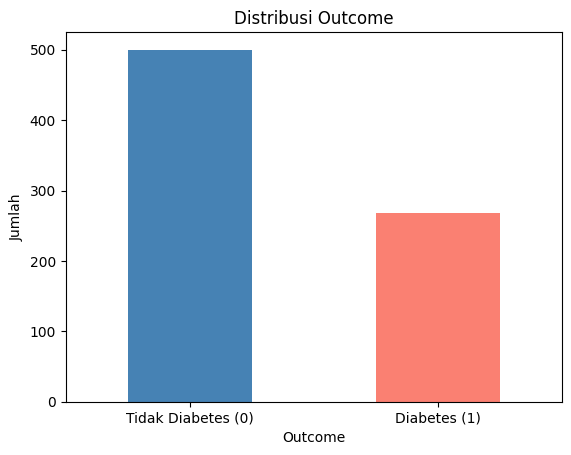

In [6]:
# distribusi target
print(df['Outcome'].value_counts())
print()

df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribusi Outcome')
plt.xticks(ticks=[0,1], labels=['Tidak Diabetes (0)', 'Diabetes (1)'], rotation=0)
plt.ylabel('Jumlah')
plt.show()

# datasetnya agak imbalanced, kelas 0 lebih banyak

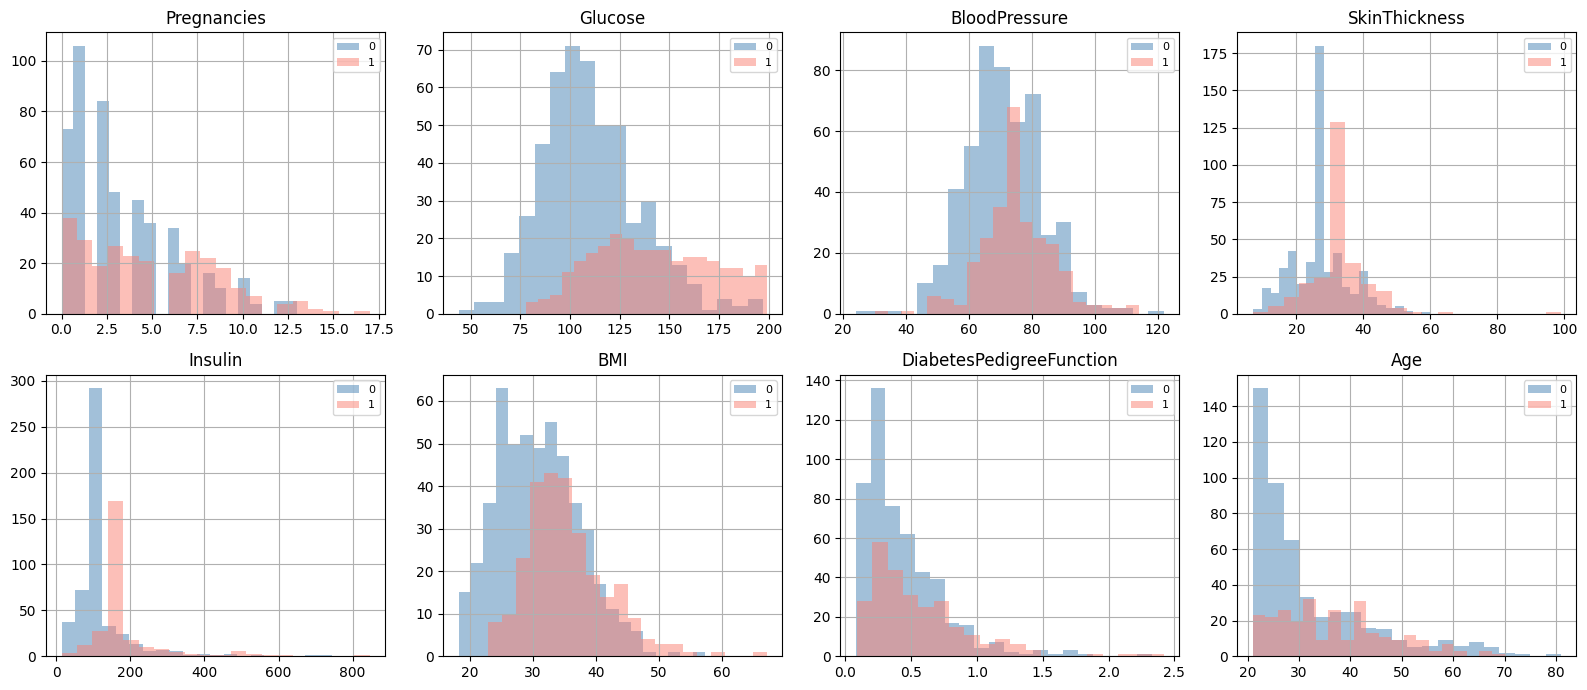

In [7]:
# distribusi tiap fitur berdasarkan outcome
features = df.columns[:-1]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    df[df['Outcome']==0][col].hist(ax=axes[i], bins=20, alpha=0.5, label='0', color='steelblue')
    df[df['Outcome']==1][col].hist(ax=axes[i], bins=20, alpha=0.5, label='1', color='salmon')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

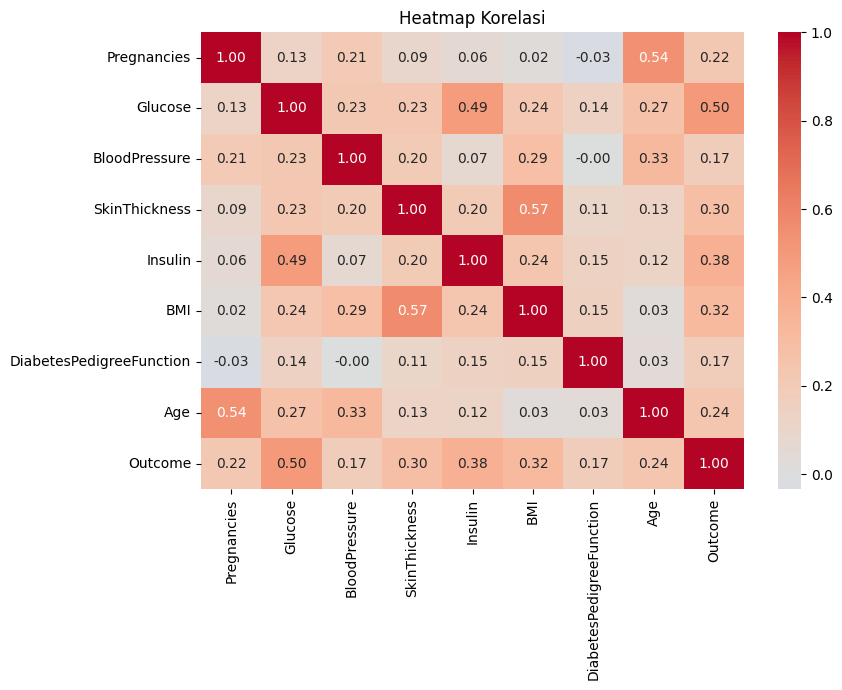

In [8]:
# korelasi antar fitur
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

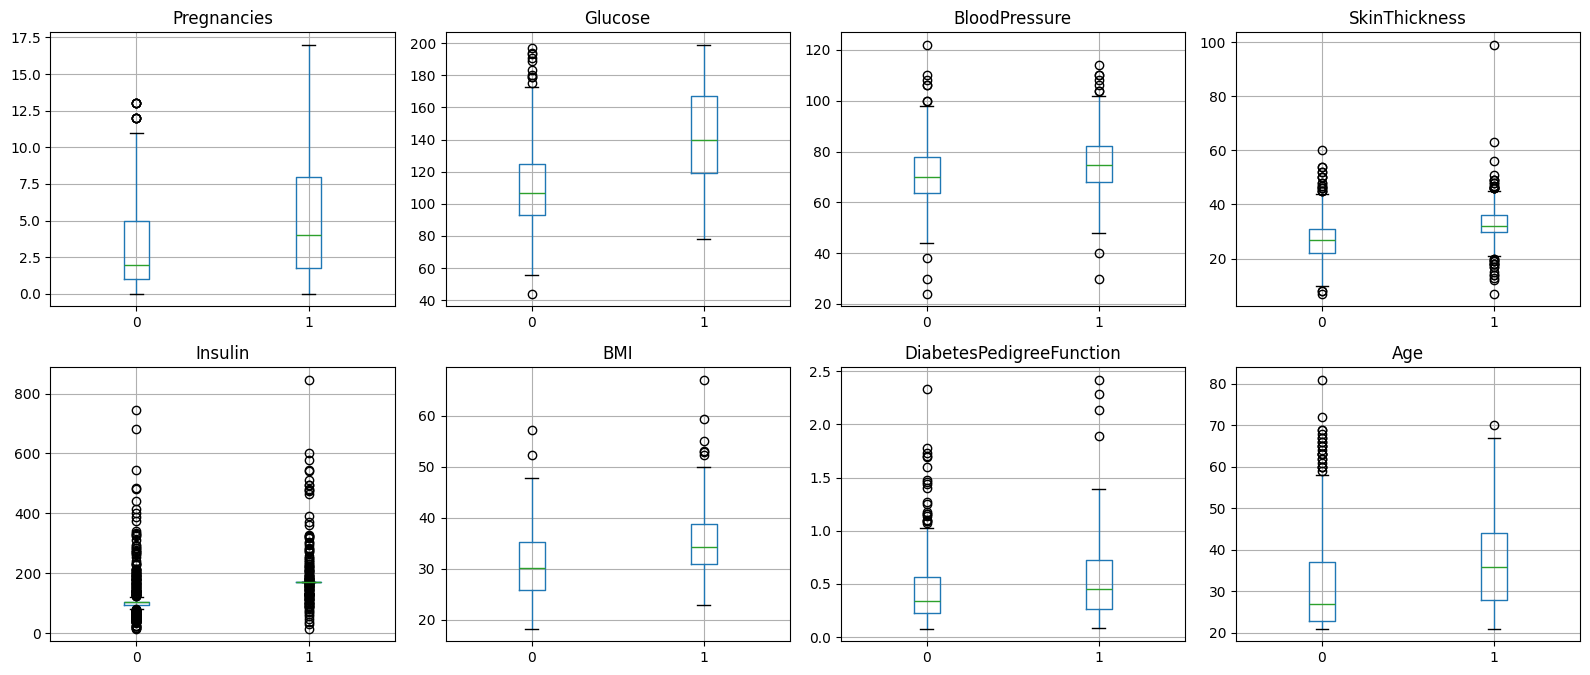

In [9]:
# boxplot buat lihat outlier
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='Outcome', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [10]:
# beberapa kolom punya nilai 0 yang ga masuk akal secara medis
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Jumlah nilai 0:')
for col in zero_cols:
    n = (df[col] == 0).sum()
    print(f'  {col}: {n}')

Jumlah nilai 0:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0


In [11]:
# ganti 0 dengan median, karena median lebih tahan outlier daripada mean
df2 = df.copy()
df2[zero_cols] = df2[zero_cols].replace(0, np.nan)

for col in zero_cols:
    med = df2[col].median()
    df2[col].fillna(med, inplace=True)
    print(f'{col} -> median: {med}')

print('\nCek masih ada NaN?', df2.isnull().sum().sum())

Glucose -> median: 117.0
BloodPressure -> median: 72.0
SkinThickness -> median: 28.0
Insulin -> median: 102.5
BMI -> median: 32.05

Cek masih ada NaN? 0


In [12]:
X = df2.drop(columns=['Outcome'])
y = df2['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 614, Test: 154


In [13]:
# scaling pake StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [14]:
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)

y_pred_gnb = gnb.predict(X_test_sc)
y_prob_gnb = gnb.predict_proba(X_test_sc)[:, 1]

print('Accuracy GNB:', accuracy_score(y_test, y_pred_gnb))

Accuracy GNB: 0.7272727272727273


## 3.2 Logistic Regression

In [15]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('Accuracy LR:', accuracy_score(y_test, y_pred_lr))

Accuracy LR: 0.7077922077922078


# 4. Evaluasi Model

In [16]:
# tabel perbandingan metrik
hasil = pd.DataFrame([
    {
        'Model': 'Gaussian NB',
        'Accuracy': round(accuracy_score(y_test, y_pred_gnb), 4),
        'Precision': round(precision_score(y_test, y_pred_gnb), 4),
        'Recall': round(recall_score(y_test, y_pred_gnb), 4),
        'F1': round(f1_score(y_test, y_pred_gnb), 4),
        'AUC': round(roc_auc_score(y_test, y_prob_gnb), 4)
    },
    {
        'Model': 'Logistic Regression',
        'Accuracy': round(accuracy_score(y_test, y_pred_lr), 4),
        'Precision': round(precision_score(y_test, y_pred_lr), 4),
        'Recall': round(recall_score(y_test, y_pred_lr), 4),
        'F1': round(f1_score(y_test, y_pred_lr), 4),
        'AUC': round(roc_auc_score(y_test, y_prob_lr), 4)
    }
])
hasil

,Model,Accuracy,Precision,Recall,F1,AUC
0,Gaussian NB,0.7273,0.6034,0.6481,0.6250,0.8017
1,Logistic Regression,0.7078,0.5882,0.5556,0.5714,0.8263


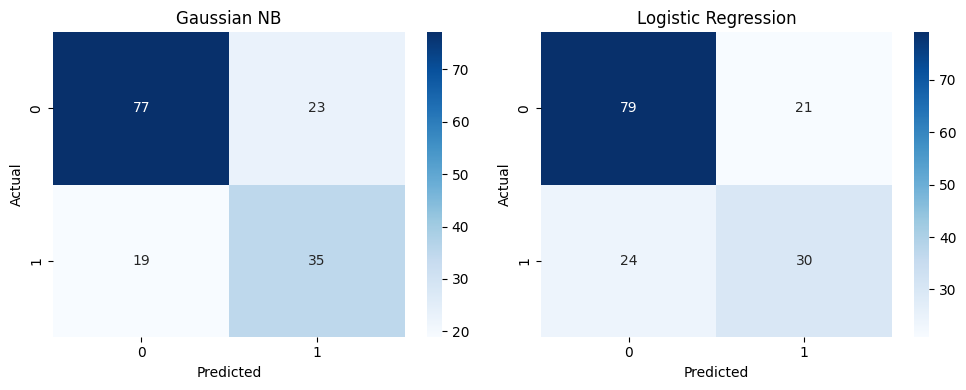

In [17]:
# confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (name, pred) in enumerate([('Gaussian NB', y_pred_gnb), ('Logistic Regression', y_pred_lr)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

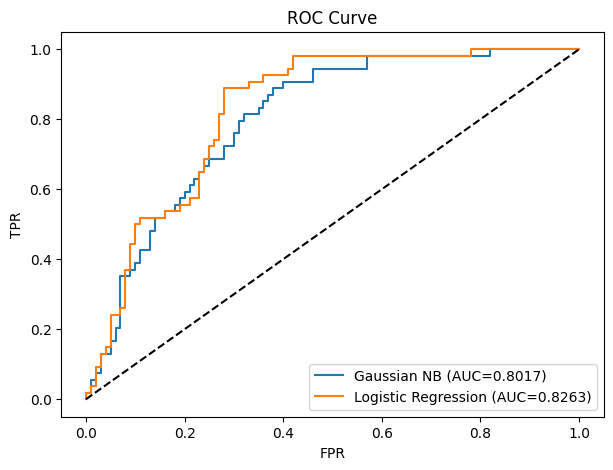

In [18]:
# ROC curve
plt.figure(figsize=(7, 5))

for name, prob in [('Gaussian NB', y_prob_gnb), ('Logistic Regression', y_prob_lr)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

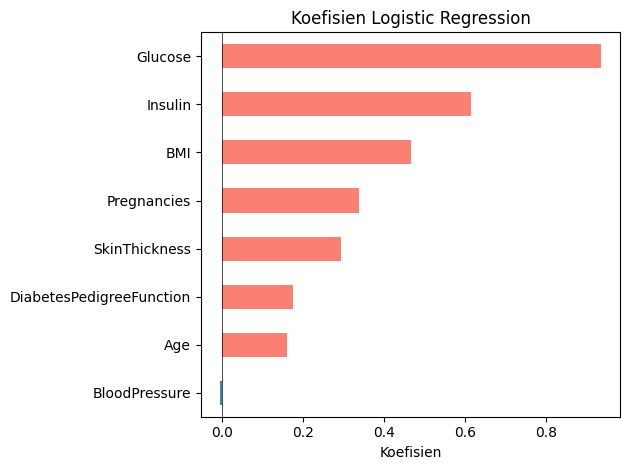

In [19]:
# koefisien logistic regression
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()

coef.plot(kind='barh', color=['steelblue' if c < 0 else 'salmon' for c in coef])
plt.title('Koefisien Logistic Regression')
plt.xlabel('Koefisien')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# positif = meningkatkan probabilitas diabetes, negatif = menurunkan

# 5. Analisis

Dari eksperimen ini, Gaussian NB dan Logistic Regression menunjukkan performa yang cukup mirip. GNB sedikit lebih unggul di accuracy dan recall, sedangkan Logistic Regression punya AUC yang lebih tinggi, artinya kemampuan membedakan kelas positif dan negatifnya secara keseluruhan lebih baik.

Yang menarik, GNB punya recall yang lebih tinggi, artinya dia lebih baik mendeteksi pasien yang benar-benar diabetes. Ini penting di konteks medis karena kita lebih nggak mau "melewatkan" pasien diabetes (false negative) daripada salah diagnosa (false positive).

Dari sisi koefisien Logistic Regression, Glucose punya pengaruh paling besar untuk memprediksi diabetes, diikuti Insulin dan BMI. Ini make sense secara medis karena kadar gula memang indikator utama diabetes. BloodPressure justru punya koefisien yang hampir nol, berarti kontribusinya kecil ke prediksi.

Salah satu keterbatasan di eksperimen ini adalah dataset yang agak imbalanced (65:35), sehingga accuracy saja kurang representatif. Maka dari itu F1-score dan AUC jadi metrik yang lebih penting untuk dilihat.

# 6. Kesimpulan dan Saran

**Kesimpulan:**

Kedua model memberikan hasil yang cukup baik untuk prediksi diabetes. Logistic Regression sedikit lebih unggul dari segi AUC, tapi Gaussian NB lebih baik di recall. Pilihan model tergantung kebutuhan, kalau prioritasnya meminimalkan false negative (pasien diabetes yang tidak terdeteksi) maka GNB lebih cocok.

Preprocessing juga berperan penting, terutama penanganan nilai 0 yang secara medis tidak mungkin dan feature scaling untuk Logistic Regression.

**Saran:**

- Bisa dicoba pakai `class_weight='balanced'` di Logistic Regression untuk handle class imbalance
- Cross-validation (misal 5-fold) bisa kasih estimasi performa yang lebih stabil
- Bisa juga coba model lain kayak Random Forest atau SVM buat perbandingan